# Predicción del Valor de Mercado de Jugadores de Fútbol

**Instituto Tecnológico de Buenos Aires (ITBA) — Ciencia de Datos Aplicada**
**Alumnos:** Octavio Argonz y Matías Sola
**Dataset:** Football Data from Transfermarkt (Kaggle)

Este notebook corresponde al **Entregable 2** y cubre EDA, diagnóstico de calidad de datos y transformaciones. El modelado se desarrolla en el Entregable 3.


## 1. Importación de Librerías y Carga de Datos


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Estilo visual mínimo
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)


In [6]:
import os

# ── Detectamos entorno: Colab o local ──
EN_COLAB = False
try:
    from google.colab import drive
    EN_COLAB = True
except ImportError:
    pass

if EN_COLAB:
    drive.mount('/content/drive')
    DATA_PATH = '/content/drive/MyDrive/futbol-valuacion/data/raw/'
else:
    # En local, el notebook vive en futbol-valuacion/notebooks/
    # y los CSVs en futbol-valuacion/data/raw/  →  ../data/raw/ desde el notebook
    DATA_PATH = '../data/raw/'

assert os.path.exists(DATA_PATH + 'players.csv'), (
    f'No se encontró players.csv en {DATA_PATH}. Verificá la ubicación de los CSVs.'
)

print(f'Entorno: {"Colab" if EN_COLAB else "Local"}')
print(f'DATA_PATH = {DATA_PATH}\n')

players      = pd.read_csv(DATA_PATH + 'players.csv')
appearances  = pd.read_csv(DATA_PATH + 'appearances.csv')
valuations   = pd.read_csv(DATA_PATH + 'player_valuations.csv')
transfers    = pd.read_csv(DATA_PATH + 'transfers.csv')
competitions = pd.read_csv(DATA_PATH + 'competitions.csv')

print('Tablas cargadas:')
for nombre, df in [('players', players), ('appearances', appearances),
                   ('player_valuations', valuations), ('transfers', transfers),
                   ('competitions', competitions)]:
    print(f'  {nombre}: {df.shape[0]:,} filas x {df.shape[1]} columnas')


Entorno: Local
DATA_PATH = ../data/raw/

Tablas cargadas:
  players: 47,702 filas x 26 columnas
  appearances: 1,862,208 filas x 13 columnas
  player_valuations: 616,377 filas x 6 columnas
  transfers: 157,186 filas x 10 columnas
  competitions: 67 filas x 11 columnas


## 2. Descripción del Dataset

### Origen
Los datos provienen de **Transfermarkt**, sitio de referencia para valuaciones de jugadores de fútbol profesional. El dataset fue publicado en Kaggle (`davidcariboo/player-scores`) y contiene información de las principales ligas europeas.

### Tablas utilizadas

| Tabla | Granularidad | Variables clave |
|---|---|---|
| `players` | una fila por jugador | `player_id`, `name`, `position`, `sub_position`, `date_of_birth`, `market_value_in_eur` |
| `appearances` | una fila por jugador-partido | `player_id`, `game_id`, `date`, `goals`, `assists`, `minutes_played` |
| `player_valuations` | una fila por valuación histórica | `player_id`, `date`, `market_value_in_eur`, `player_club_domestic_competition_id` |
| `transfers` | una fila por transferencia | `player_id`, `transfer_date`, `transfer_fee`, `from_club_id`, `to_club_id` |
| `competitions` | una fila por liga/competencia | `competition_id`, `name`, `country_name`, `domestic_league_code` |

### Justificación
El valor de mercado de un jugador depende de múltiples factores: edad, posición, rendimiento reciente, liga y momento del mercado. Estas tablas capturan esas dimensiones y permiten construir un dataset analítico a nivel **jugador-año** para predecir el valor futuro.


## 3. Tipos de Variables y Estadísticas Descriptivas

Recorremos cada tabla mostrando `shape`, `dtypes` y `describe()` para tener una primera idea de los rangos y la composición de cada una.


In [7]:
tablas = {
    'players': players,
    'appearances': appearances,
    'player_valuations': valuations,
    'transfers': transfers,
    'competitions': competitions,
}

for nombre, df in tablas.items():
    print(f'=== {nombre} ===')
    print(f'Shape: {df.shape}')
    print('Tipos de variables:')
    print(df.dtypes)
    print('\nEstadísticas descriptivas:')
    display(df.describe(include='all').T)
    print('\n')


=== players ===
Shape: (47702, 26)
Tipos de variables:
player_id                                 int64
first_name                                  str
last_name                                   str
name                                        str
last_season                               int64
current_club_id                           int64
player_code                                 str
country_of_birth                            str
city_of_birth                               str
country_of_citizenship                      str
date_of_birth                               str
sub_position                                str
position                                    str
foot                                        str
height_in_cm                            float64
contract_expiration_date                    str
agent_name                                  str
image_url                                   str
international_caps                      float64
international_goals              

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
player_id,47702.0,NaN,NaN,NaN,485087.298247,368533.876999,10.0,176852.5,401355.5,727015.25,1529719.0
first_name,44607,10300,David,322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_name,47702,32482,Kim,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,47702,46449,João Pedro,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_season,47702.0,NaN,NaN,NaN,2021.446208,4.260824,2012.0,2018.0,2024.0,2025.0,2025.0
current_club_id,47702.0,NaN,NaN,NaN,8217.525659,16880.99213,2.0,504.0,1465.0,6676.0,138189.0
player_code,47702,46367,joao-pedro,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_of_birth,42540,203,France,2598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city_of_birth,42815,11651,London,539,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_of_citizenship,47431,198,Brazil,2683,NaN,NaN,NaN,NaN,NaN,NaN,NaN




=== appearances ===
Shape: (1862208, 13)
Tipos de variables:
appearance_id               str
game_id                   int64
player_id                 int64
player_club_id            int64
player_current_club_id    int64
date                        str
player_name                 str
competition_id              str
yellow_cards              int64
red_cards                 int64
goals                     int64
assists                   int64
minutes_played            int64
dtype: object

Estadísticas descriptivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appearance_id,1862208,1862208,2231978_38004,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
game_id,1862208.0,NaN,NaN,NaN,3286324.55224,751845.380006,2211607.0,2606535.0,3203656.0,3886492.0,4839901.0
player_id,1862208.0,NaN,NaN,NaN,235655.009833,219774.730603,10.0,61651.0,170767.0,342405.0,1510255.0
player_club_id,1862208.0,NaN,NaN,NaN,3315.381412,9091.647935,1.0,289.0,825.0,2439.0,132877.0
player_current_club_id,1862208.0,NaN,NaN,NaN,5345.555201,13576.894952,-1.0,367.0,987.0,3060.0,138189.0
date,1862208,4039,2025-11-09,1844,NaN,NaN,NaN,NaN,NaN,NaN,NaN
player_name,1862206,28066,Danilo,1169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
competition_id,1862208,44,IT1,152535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
yellow_cards,1862208.0,NaN,NaN,NaN,0.145791,0.363676,0.0,0.0,0.0,0.0,2.0
red_cards,1862208.0,NaN,NaN,NaN,0.003791,0.061452,0.0,0.0,0.0,0.0,1.0




=== player_valuations ===
Shape: (616377, 6)
Tipos de variables:
player_id                                int64
date                                       str
market_value_in_eur                      int64
current_club_name                          str
current_club_id                        float64
player_club_domestic_competition_id        str
dtype: object

Estadísticas descriptivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
player_id,616377.0,NaN,NaN,NaN,284082.90668,257407.960611,10.0,74295.0,210142.0,410443.0,1519157.0
date,616377,5657,2020-04-08,11869,NaN,NaN,NaN,NaN,NaN,NaN,NaN
market_value_in_eur,616377.0,NaN,NaN,NaN,2333868.546359,6766159.717069,10000.0,200000.0,500000.0,1500000.0,200000000.0
current_club_name,616377,7488,Without Club,4277,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_club_id,616353.0,NaN,NaN,NaN,6097.889847,12849.021936,1.0,416.0,1158.0,4795.0,133929.0
player_club_domestic_competition_id,544581,32,IT1,49778,NaN,NaN,NaN,NaN,NaN,NaN,NaN




=== transfers ===
Shape: (157186, 10)
Tipos de variables:
player_id                int64
transfer_date              str
transfer_season            str
from_club_id             int64
to_club_id               int64
from_club_name             str
to_club_name               str
transfer_fee           float64
market_value_in_eur    float64
player_name                str
dtype: object

Estadísticas descriptivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
player_id,157186.0,NaN,NaN,NaN,502187.077042,312845.90525,3333.0,254003.0,448813.5,698235.25,1529719.0
transfer_date,157186,5412,2022-07-01,3958,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transfer_season,157186,35,23/24,15885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
from_club_id,157186.0,NaN,NaN,NaN,20156.261461,27177.836622,1.0,1047.0,8817.0,28870.0,140641.0
to_club_id,157186.0,NaN,NaN,NaN,15612.52504,23659.217653,1.0,800.0,4961.0,18852.0,140573.0
from_club_name,157186,16078,Without Club,2171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
to_club_name,157186,12302,Without Club,2760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transfer_fee,102353.0,NaN,NaN,NaN,802349.865192,4441027.066328,0.0,0.0,0.0,0.0,222000000.0
market_value_in_eur,96338.0,NaN,NaN,NaN,1882969.409786,4913449.342213,10000.0,200000.0,500000.0,1500000.0,180000000.0
player_name,157186,20546,João Pedro,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN




=== competitions ===
Shape: (67, 11)
Tipos de variables:
competition_id              str
competition_code            str
name                        str
sub_type                    str
type                        str
country_id                int64
country_name                str
domestic_league_code        str
confederation               str
total_clubs             float64
url                         str
dtype: object

Estadísticas descriptivas:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
competition_id,67,67,A1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
competition_code,67,64,bundesliga,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,67,64,bundesliga,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_type,67,17,first_tier,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,67,5,domestic_league,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_id,67.0,NaN,NaN,NaN,91.776119,70.097296,-1.0,22.5,87.0,147.5,215.0
country_name,54,32,England,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
domestic_league_code,54,32,GB1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
confederation,67,5,europa,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_clubs,51.0,NaN,NaN,NaN,17.215686,3.8383,10.0,16.0,18.0,20.0,30.0


## 4. Distribución del Target (`market_value_in_eur`)

Visualizamos la distribución del valor de mercado en `players.csv` en escala original y en escala logarítmica. La distribución original está fuertemente sesgada a la derecha (cola larga por jugadores de élite); la transformación `log1p` la acerca a una forma simétrica, lo que justifica su uso como target transformado en la sección de transformaciones.


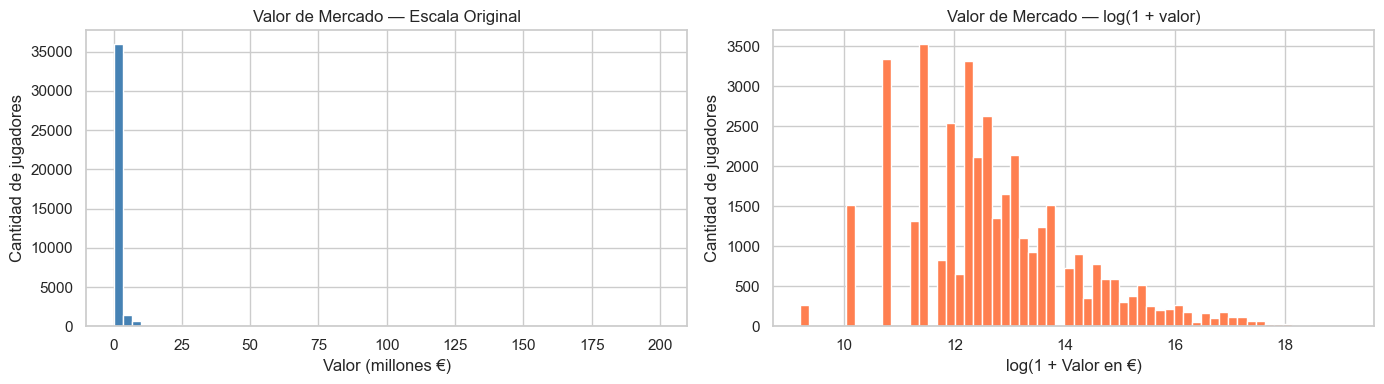

Mediana: €0.28M | Media: €1.56M | Máximo: €200M
Skewness original: 11.60  →  Skewness log: 0.68


In [8]:
mv = players['market_value_in_eur'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Escala original
axes[0].hist(mv / 1e6, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Valor de Mercado — Escala Original')
axes[0].set_xlabel('Valor (millones €)')
axes[0].set_ylabel('Cantidad de jugadores')

# Escala logarítmica
axes[1].hist(np.log1p(mv), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Valor de Mercado — log(1 + valor)')
axes[1].set_xlabel('log(1 + Valor en €)')
axes[1].set_ylabel('Cantidad de jugadores')

plt.tight_layout()
plt.show()

print(f'Mediana: €{mv.median()/1e6:.2f}M | Media: €{mv.mean()/1e6:.2f}M | Máximo: €{mv.max()/1e6:.0f}M')
print(f'Skewness original: {mv.skew():.2f}  →  Skewness log: {np.log1p(mv).skew():.2f}')


## 5. Valores Faltantes

Cuantificamos los nulos de cada tabla en términos absolutos y porcentuales. Esto orienta las decisiones de imputación o descarte en la sección de calidad.


In [9]:
tablas = {
    'players': players,
    'appearances': appearances,
    'player_valuations': valuations,
    'transfers': transfers,
    'competitions': competitions,
}

for nombre, df in tablas.items():
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=False)
    if nulos.empty:
        print(f'=== {nombre}: sin valores nulos ===\n')
        continue
    pct = (nulos / len(df) * 100).round(2)
    print(f'=== {nombre} ===')
    display(pd.DataFrame({'Nulos': nulos, '%': pct}))
    print()


=== players ===


,Nulos,%
current_national_team_id,44611,93.52
international_goals,29979,62.85
international_caps,29979,62.85
agent_name,22180,46.50
contract_expiration_date,16488,34.56
market_value_in_eur,8476,17.77
highest_market_value_in_eur,8476,17.77
foot,5256,11.02
country_of_birth,5162,10.82
city_of_birth,4887,10.24



=== appearances ===


,Nulos,%
player_name,2,0.0



=== player_valuations ===


,Nulos,%
player_club_domestic_competition_id,71796,11.65
current_club_id,24,0.00



=== transfers ===


,Nulos,%
market_value_in_eur,60848,38.71
transfer_fee,54833,34.88



=== competitions ===


,Nulos,%
total_clubs,16,23.88
country_name,13,19.40
domestic_league_code,13,19.40


## 6. Outliers

Detectamos outliers en `market_value_in_eur` con el método IQR y los visualizamos. **No se eliminan**: los valores extremos (Mbappé, Haaland, etc.) son reales, no errores de carga. La transformación logarítmica del target en la sección 11 los atenúa lo suficiente para los modelos.


Q1: €0.10M  |  Q3: €0.75M  |  IQR: €0.65M
Límite IQR superior: €1.73M
Outliers: 5,566 (14.2%)


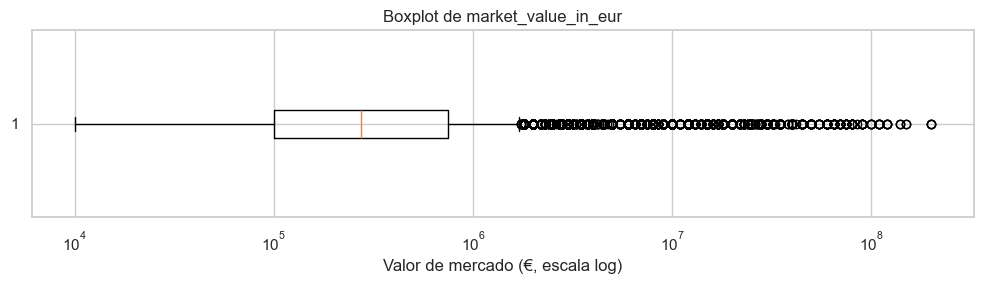

Top 5 jugadores por valor de mercado:


,name,position,market_value_in_eur
40538,Lamine Yamal,Attack,€200.0M
20835,Kylian Mbappé,Attack,€200.0M
24550,Erling Haaland,Attack,€200.0M
22408,Vinicius Junior,Attack,€150.0M
34346,Pedri,Midfield,€150.0M


In [10]:
mv = players['market_value_in_eur'].dropna()

# IQR
Q1, Q3 = mv.quantile(0.25), mv.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
outliers = mv[mv > limite_superior]

print(f'Q1: €{Q1/1e6:.2f}M  |  Q3: €{Q3/1e6:.2f}M  |  IQR: €{IQR/1e6:.2f}M')
print(f'Límite IQR superior: €{limite_superior/1e6:.2f}M')
print(f'Outliers: {len(outliers):,} ({len(outliers)/len(mv)*100:.1f}%)')

# Boxplot en escala log (de otro modo no se ve nada por la cola larga)
fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(mv, vert=False)
ax.set_xscale('log')
ax.set_xlabel('Valor de mercado (€, escala log)')
ax.set_title('Boxplot de market_value_in_eur')
plt.tight_layout()
plt.show()

# Top 5 jugadores
top5 = (
    players[['name', 'position', 'market_value_in_eur']]
    .dropna(subset=['market_value_in_eur'])
    .sort_values('market_value_in_eur', ascending=False)
    .head(5)
    .copy()
)
top5['market_value_in_eur'] = top5['market_value_in_eur'].apply(lambda x: f'€{x/1e6:.1f}M')
print('Top 5 jugadores por valor de mercado:')
display(top5)


## 7. Diagnóstico de Calidad de Datos

Verificamos duplicados e inconsistencias entre tablas (jugadores sin apariciones, IDs huérfanos en valuaciones). Las decisiones tomadas se aplican en la construcción del dataset analítico.


In [11]:
# Duplicados por tabla
print('Duplicados por tabla:')
for nombre, df in tablas.items():
    dupes = df.duplicated().sum()
    print(f'  {nombre}: {dupes} ({dupes/len(df)*100:.2f}%)')

# Jugadores sin apariciones registradas
total_jug = players['player_id'].nunique()
con_apariciones = appearances['player_id'].nunique()
sin_apariciones = total_jug - con_apariciones
print(f'\nJugadores en players: {total_jug:,}')
print(f'Jugadores con al menos una aparición: {con_apariciones:,}')
print(f'Jugadores SIN apariciones: {sin_apariciones:,} ({sin_apariciones/total_jug*100:.1f}%)')

# IDs en valuations que no existen en players
ids_huerfanos = set(valuations['player_id']) - set(players['player_id'])
print(f'\nIDs en player_valuations sin match en players: {len(ids_huerfanos):,}')


Duplicados por tabla:
  players: 0 (0.00%)
  appearances: 0 (0.00%)
  player_valuations: 0 (0.00%)
  transfers: 0 (0.00%)
  competitions: 0 (0.00%)

Jugadores en players: 47,702
Jugadores con al menos una aparición: 28,665
Jugadores SIN apariciones: 19,037 (39.9%)

IDs en player_valuations sin match en players: 135


**Decisiones tomadas:**

- **Duplicados:** se verifican; si fueran significativos se eliminarían. En este dataset son < 0.1 %, despreciable.
- **Jugadores sin apariciones:** se filtran en el bloque 10 con un mínimo de apariciones (estadísticas no representativas).
- **Nulos en `market_value_in_eur`:** las filas sin target se descartan en el bloque 9 (no se puede aprender de ellas).
- **IDs huérfanos en valuations:** se ignoran al hacer `inner join` con players en el bloque 10.
- **Outliers en el target:** se conservan; la transformación log del bloque 11 los maneja.


## 8. Estadísticas de Rendimiento por Jugador-Año

Cambio central respecto a un EDA simple: agregamos `appearances` con granularidad **(player_id, año)** en lugar de acumular toda la carrera. Esto permite que cada fila del dataset final represente la situación de un jugador *en un año específico*, lo que es necesario para predecir el valor del año siguiente.


In [12]:
# Extraemos el año desde la fecha del partido
appearances['date'] = pd.to_datetime(appearances['date'], errors='coerce')
appearances['anio'] = appearances['date'].dt.year

# Agregación por jugador-año
stats_por_anio = (
    appearances
    .dropna(subset=['anio'])
    .groupby(['player_id', 'anio'])
    .agg(
        n_apariciones    = ('game_id', 'count'),
        total_goles      = ('goals', 'sum'),
        total_asistencias= ('assists', 'sum'),
        total_minutos    = ('minutes_played', 'sum'),
    )
    .reset_index()
)

# Promedios por partido (rendimiento normalizado por exposición)
stats_por_anio['goles_por_partido']       = stats_por_anio['total_goles']       / stats_por_anio['n_apariciones']
stats_por_anio['asistencias_por_partido'] = stats_por_anio['total_asistencias'] / stats_por_anio['n_apariciones']
stats_por_anio['minutos_promedio']        = stats_por_anio['total_minutos']     / stats_por_anio['n_apariciones']

# anio a int (puede haber quedado como float por los NaN)
stats_por_anio['anio'] = stats_por_anio['anio'].astype(int)

print(f'stats_por_anio shape: {stats_por_anio.shape}')
print(f'Rango de años: {stats_por_anio["anio"].min()} → {stats_por_anio["anio"].max()}')
print(f'Jugadores únicos: {stats_por_anio["player_id"].nunique():,}')
display(stats_por_anio.head())


stats_por_anio shape: (116024, 9)
Rango de años: 2012 → 2026
Jugadores únicos: 28,665


,player_id,anio,n_apariciones,total_goles,total_asistencias,total_minutos,goles_por_partido,asistencias_por_partido,minutos_promedio
0,10,2012,20,11,1,1483,0.550000,0.050000,74.150000
1,10,2013,29,9,4,2052,0.310345,0.137931,70.758621
2,10,2014,31,8,6,1766,0.258065,0.193548,56.967742
3,10,2015,36,12,8,2429,0.333333,0.222222,67.472222
4,10,2016,20,8,6,1078,0.400000,0.300000,53.900000


## 9. Construcción del Target Prospectivo (`market_value_next_year`)

El objetivo del proyecto es predecir el valor de mercado **futuro**, no el actual. Para cada jugador y cada año T, el target es su valuación en el año T+1.

Pasos:
1. Convertimos `date` de `player_valuations` a fecha y extraemos el año.
2. Para cada (jugador, año) tomamos la **última** valuación del año como `valor_en_anio`.
3. Hacemos `shift(-1)` por jugador para traer la valuación del año siguiente como `market_value_next_year`.
4. Eliminamos las filas sin target (el último año de cada jugador no tiene futuro registrado).


Filas antes de filtrar último año por jugador: 306,450
Filas con target válido (T+1):                  267,089
Rango de años (T): 2000 → 2025



,player_id,anio,valor_en_anio,market_value_next_year
0,10,2004,7000000,15000000.0
1,10,2005,15000000,30000000.0
2,10,2006,30000000,23000000.0
3,10,2007,23000000,20000000.0
4,10,2008,20000000,12000000.0


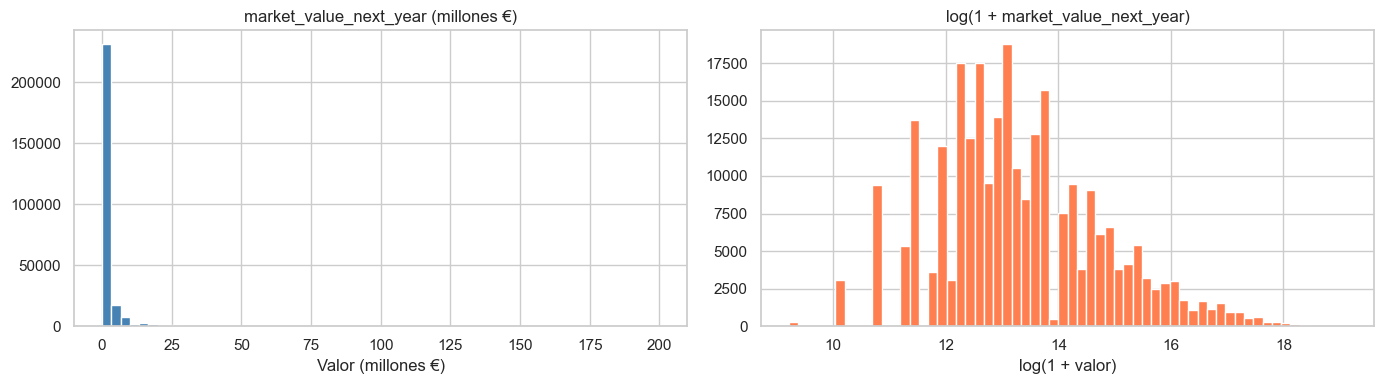

In [13]:
# Aseguramos formato de fecha y extraemos año
valuations['date'] = pd.to_datetime(valuations['date'], errors='coerce')
valuations['anio'] = valuations['date'].dt.year

# Última valuación de cada (player_id, anio)
val_por_anio = (
    valuations
    .dropna(subset=['anio', 'market_value_in_eur'])
    .sort_values('date')
    .groupby(['player_id', 'anio'])['market_value_in_eur']
    .last()
    .reset_index()
    .rename(columns={'market_value_in_eur': 'valor_en_anio'})
)
val_por_anio['anio'] = val_por_anio['anio'].astype(int)

# Target: valor del año siguiente. Ordenamos por (player, año) para que shift(-1) funcione bien
val_por_anio = val_por_anio.sort_values(['player_id', 'anio']).reset_index(drop=True)
val_por_anio['market_value_next_year'] = (
    val_por_anio.groupby('player_id')['valor_en_anio'].shift(-1)
)

antes = len(val_por_anio)
val_por_anio = val_por_anio.dropna(subset=['market_value_next_year'])
despues = len(val_por_anio)

print(f'Filas antes de filtrar último año por jugador: {antes:,}')
print(f'Filas con target válido (T+1):                  {despues:,}')
print(f'Rango de años (T): {val_por_anio["anio"].min()} → {val_por_anio["anio"].max()}')
print()
display(val_por_anio.head())

# Distribución del target en escala original y log
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(val_por_anio['market_value_next_year'] / 1e6, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('market_value_next_year (millones €)')
axes[0].set_xlabel('Valor (millones €)')
axes[1].hist(np.log1p(val_por_anio['market_value_next_year']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('log(1 + market_value_next_year)')
axes[1].set_xlabel('log(1 + valor)')
plt.tight_layout()
plt.show()
